In [1]:
import torch

## 1.Calculate the attention score 


### Lets create a tesnor and calc the dot product

- The higher the dot product value --> the more simillar those vectors to each other
- And vice versa


In [2]:
inputs = torch.tensor([[0.43, 0.15, 0.89], # Your --> x1
                      [0.55 , 0.87, 0.66], # Journey --> x2
                      [0.57, 0.85, 0.64], # starts --> x3
                      [0.22, 0.58, 0.33], #with --> x4
                      [0.77, 0.25, 0.10], # one --> x5
                      [0.05, 0.80,0.55]] # step --> x6
                      
                      
                      
                      )
                      

In [3]:
inputs.shape

torch.Size([6, 3])

In [4]:
query = inputs[1]
attn_score_dot = torch.empty(inputs.shape[0]) # inputs shape [0] ==6, to calc the dot product for each token i have
attn_score_cos = torch.empty(inputs.shape[0]) # inputs shape [0] ==6, to calc the cosine similarity for each token i have

attn_score_dot

tensor([0., 0., 0., 0., 0., 0.])

In [5]:
# for each position in attn_score --> replace it with the dot product 
for i , x_i in enumerate(inputs):
    attn_score_dot [i] =torch.dot(query,x_i)
    attn_score_cos[i] = torch.cosine_similarity(query,x_i,dim=0)

print(f"Dot product scores: {attn_score_dot}")
print(f"Cosine similarity scores: {attn_score_cos}")

Dot product scores: tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Cosine similarity scores: tensor([0.7808, 1.0000, 0.9997, 0.9817, 0.7089, 0.9141])


> The conclusion is the same, the one with highest dot product has the highest cos sim and vice versa

#### This is an experiment 

- TO see is there any difference between dot product and cosine similarity in 2D or not

In [6]:
# create (6,2) tensor embeddings

inputs_2d_embeddings = torch.tensor([[0.1, 0.2], # Your --> x1
                      [0.3 , 0.4], # Journey --> x2
                        [0.5, 0.6], # starts --> x3
                        [0.7, 0.8], #with --> x4
                        [0.9, 1.0], # one --> x5
                        [1.1, 1.2]] # step --> x6
                        
                        
                        
                        )

inputs_2d_embeddings.shape

torch.Size([6, 2])

In [7]:
input_2d_dot = torch.empty(inputs_2d_embeddings.shape[0],dtype=torch.float32) # inputs shape [0] ==6, to calc the dot product for each token i have
input_2d_cos = torch.empty(inputs_2d_embeddings.shape[0],dtype=torch.float32) # inputs shape [0] ==6, to calc the cosine similarity for each token i have

query = inputs_2d_embeddings[1]

for  i , x_i in enumerate(inputs_2d_embeddings):
    input_2d_dot[i] = torch.dot(query,x_i)
    input_2d_cos[i] = torch.cosine_similarity(query,x_i,dim=0)

print(f"Dot product scores for 2D embeddings: {input_2d_dot}")
print(f"Cosine similarity scores for 2D embeddings: {input_2d_cos}")

Dot product scores for 2D embeddings: tensor([0.1100, 0.2500, 0.3900, 0.5300, 0.6700, 0.8100])
Cosine similarity scores for 2D embeddings: tensor([0.9839, 1.0000, 0.9987, 0.9972, 0.9960, 0.9952])


## 2. Normalize the attention score 

- To sum up with 1


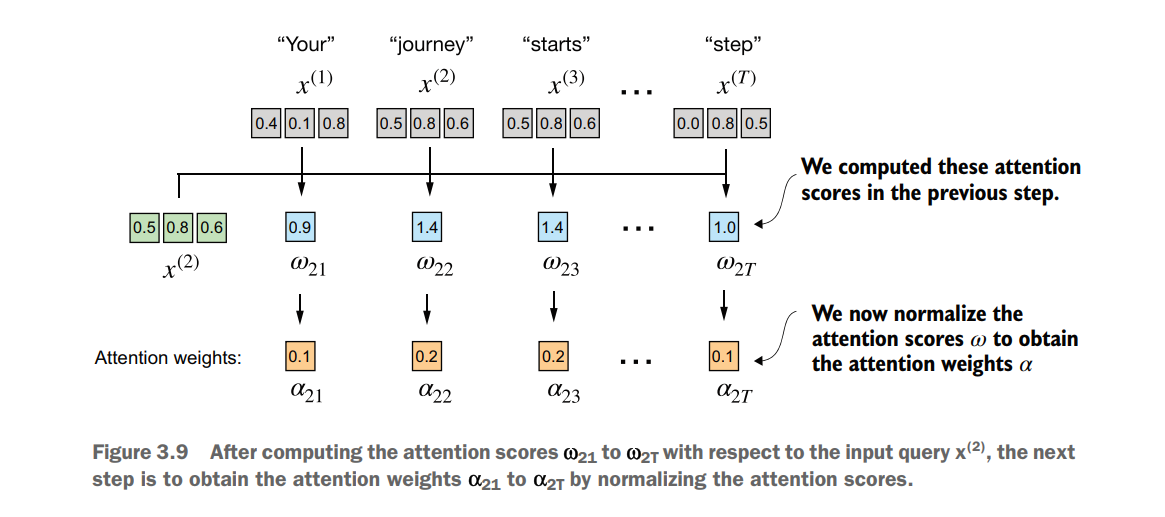

In [8]:
attn_score_dot

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

In [9]:
attn_score_2_temp = attn_score_dot / torch.sum(attn_score_dot)
print(f"Attention scores after normalization: {attn_score_2_temp}")
print(f"Summation of attention weights after normalization: {torch.sum(attn_score_2_temp)}")

Attention scores after normalization: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Summation of attention weights after normalization: 1.0000001192092896


### Normalization using softmax

- It is recommended to use softmax in normalization because it has more favorable gradient properties during training
- Because it handles the extreme values more better 

In [10]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

In [11]:
attn_weights_2_naive = softmax_naive(attn_score_dot)
print(f"Attention weights after softmax normalization: {attn_weights_2_naive}")
print(f"Summation of attention weights after softmax normalization: {torch.sum(attn_weights_2_naive)}")

Attention weights after softmax normalization: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Summation of attention weights after softmax normalization: 1.0


### Its advisable to use softmax from pytorch
- because there is sometimes naive softmax may encounter numerical instability, such as overflow or underflow
- Pytorch.softmax is optimized for those scenarios  

In [12]:
att_weights_2 = torch.softmax(attn_score_dot,dim=0)
print(f"Attention weights after PyTorch softmax normalization: {att_weights_2}")
print(f"Summation of attention weights after PyTorch softmax normalization: {torch.sum(att_weights_2)}")

Attention weights after PyTorch softmax normalization: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Summation of attention weights after PyTorch softmax normalization: 1.0


## Third step

- Calculating the `Context Vector` for each token
- `Context Vector` is the weighted sum of all input vectors


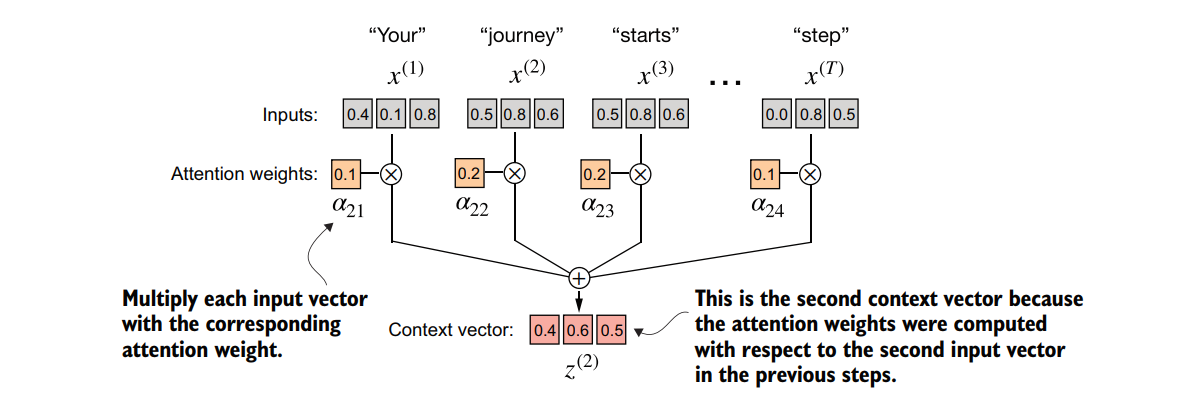

In [13]:
att_weights_2

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

In [14]:
inputs[2],att_weights_2[2]

(tensor([0.5700, 0.8500, 0.6400]), tensor(0.2333))

In [15]:
# i calc the attention with its weight and sum them up to get the context vector
x = torch.tensor([0.43, 0.15, 0.89]) # Your --> x1
first = inputs[0] * att_weights_2[0]
x += first
second = inputs[1] * att_weights_2[1]
x += second
third = inputs[2] * att_weights_2[2]
x += third
fourth = inputs[3] * att_weights_2[3]
x += fourth
fifth = inputs[4] * att_weights_2[4]
x += fifth

print(x)

tensor([0.8640, 0.6750, 1.3713])


In [16]:
query = inputs[1]
context_vector_2 = torch.zeros(query.shape) # initialize a zero vector with the same shape as the query

for idx , x_i in enumerate(inputs):
    context_vector_2 += att_weights_2[idx] * x_i
     
print(context_vector_2)

tensor([0.4419, 0.6515, 0.5683])


## Generalized way to calc the attention scores 

- Now we are on the first step : calc the attention scores

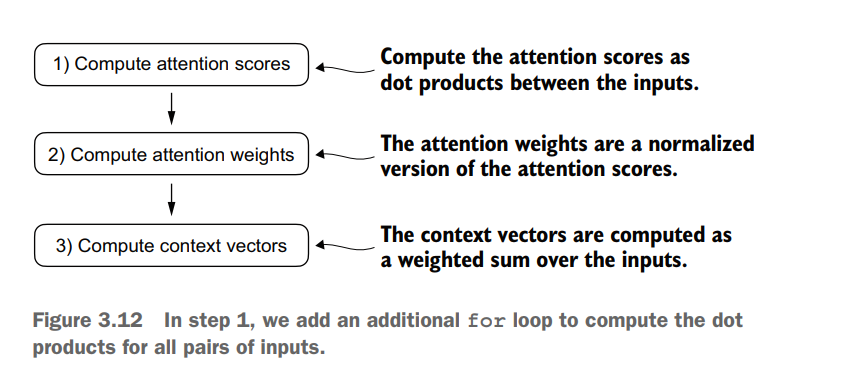

### Calculate the attention scores 

- Dot product between all the tokens

In [17]:
attn_scores = torch.empty(6,6)
# i will have 6 rows , each represents input token
# i will have also 6 columns , each represents the attention score of the token with respect to the other tokens (including itself)
attn_scores.shape

torch.Size([6, 6])

In [18]:
for row_index , x_i in enumerate(inputs):
    for col_index, x_j in enumerate(inputs):
        attn_scores[row_index,col_index] = torch.dot(x_i,x_j) 


print(f"Attention scores for all the inputs : \n{attn_scores}")


Attention scores for all the inputs : 
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


#### `Matrix Multiplication` instead of For loop

In [19]:
attn_scores = inputs @ inputs.T
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

### calculate the attention weights

- Normalized version of attention score 

In [20]:
attn_weights = torch.softmax(attn_scores, dim=-1)
# since dimension here is (row , columns)
# dim = -1 --> last dim --> apply it on columns 
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [21]:
print(f"All rows sum: \n{torch.sum(attn_weights,dim=0)}")

All rows sum: 
tensor([0.9220, 1.2970, 1.2788, 0.7974, 0.7540, 0.9508])


## Pytorch Dims 

In [22]:
torch.manual_seed(112)
rand = torch.rand(5,4)
rand

tensor([[0.0146, 0.1393, 0.9180, 0.3637],
        [0.2042, 0.6238, 0.3734, 0.9844],
        [0.8940, 0.8942, 0.1829, 0.6861],
        [0.0303, 0.1681, 0.3254, 0.9734],
        [0.6500, 0.1076, 0.9207, 0.3746]])

In [23]:
print(f"Sum accross rows : \n{torch.sum(rand,dim=0)}")

Sum accross rows : 
tensor([1.7931, 1.9330, 2.7204, 3.3823])


In [24]:
print(f"Sum accross columns : \n{torch.sum(rand,dim=1)}")

Sum accross columns : 
tensor([1.4357, 2.1859, 2.6572, 1.4972, 2.0529])


In [25]:
torch.sum(torch.tensor([[0.8940, 0.8942, 0.1829, 0.6861]]))

tensor(2.6572)

In [26]:
torch.sum(torch.tensor([0.0146, 0.1393, 0.9180, 0.3637]))

tensor(1.4356)

## Continue from softtmax

In [27]:
attn_weights = torch.softmax(attn_scores, dim=-1)
# since dimension here is (row , columns)
# dim = -1 --> last dim --> apply it on columns 
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [28]:
print(f"All rows sum: \n{torch.sum(attn_weights,dim=0)}")

All rows sum: 
tensor([0.9220, 1.2970, 1.2788, 0.7974, 0.7540, 0.9508])


### 3. Use attention weights to comute context vector

In [29]:
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [30]:
all_context_vectors = attn_weights @ inputs
all_context_vectors

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

# Self Attention Mechanism

- Introducing the concept of W_q , W_v and W_k

## forming the new 3 matrices

- Calc W_q, W_v and W_q for x_2

In [31]:
x_2 = inputs[1]
x_2

tensor([0.5500, 0.8700, 0.6600])

In [32]:
d_in = x_2.shape[0]
d_in

3

In [33]:
d_out = 2

In [34]:
torch.manual_seed(123)
w_q = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
w_k = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
w_v = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)

w_q

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])

In [35]:
q_2 = x_2 @ w_q
v_2 = x_2 @ w_v
k_2 = x_2 @ w_k

print(f"Query vector for x_2: {q_2}")
print(f"Key vector for x_2: {k_2}")
print(f"Value vector for x_2: {v_2}")

Query vector for x_2: tensor([0.4306, 1.4551])
Key vector for x_2: tensor([0.4433, 1.1419])
Value vector for x_2: tensor([0.3951, 1.0037])


### Since we want to get the context_vector of q_2

- We will calc the w_k and w_v for the whole inputs

In [36]:
keys = inputs @ w_k
values = inputs @ w_v

print(f" Keys shape: {keys.shape}")
print(f"Keys for all inputs: \n{keys}")

print(f"--------------------------------------------")

print(f"Values shape: {values.shape}")
print(f"Values for all inputs: \n{values}")

 Keys shape: torch.Size([6, 2])
Keys for all inputs: 
tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])
--------------------------------------------
Values shape: torch.Size([6, 2])
Values for all inputs: 
tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]])


In [37]:
q_2.shape , keys.T.shape

(torch.Size([2]), torch.Size([2, 6]))

In [38]:
q_2

tensor([0.4306, 1.4551])

In [39]:
keys.T

tensor([[0.3669, 0.4433, 0.4361, 0.2408, 0.1827, 0.3275],
        [0.7646, 1.1419, 1.1156, 0.6706, 0.3292, 0.9642]])

In [40]:
# now we have all keys and values for all the inputs
# we need to calc the context vector for x_2

d_k = keys.shape[-1]

attn_scores_2 = q_2 @ keys.T
attn_scores_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])

#### Divide the softmax by `sqrt of the embed_dim` for stability

In [41]:
attn_weights_2 = torch.softmax(attn_scores_2 / d_k **0.5  , dim=-1)
attn_weights_2

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])

In [42]:
values

tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]])

In [43]:
cont_vec_2 = attn_weights_2 @ values
cont_vec_2

tensor([0.3061, 0.8210])

In [44]:
cont_vec_2

tensor([0.3061, 0.8210])

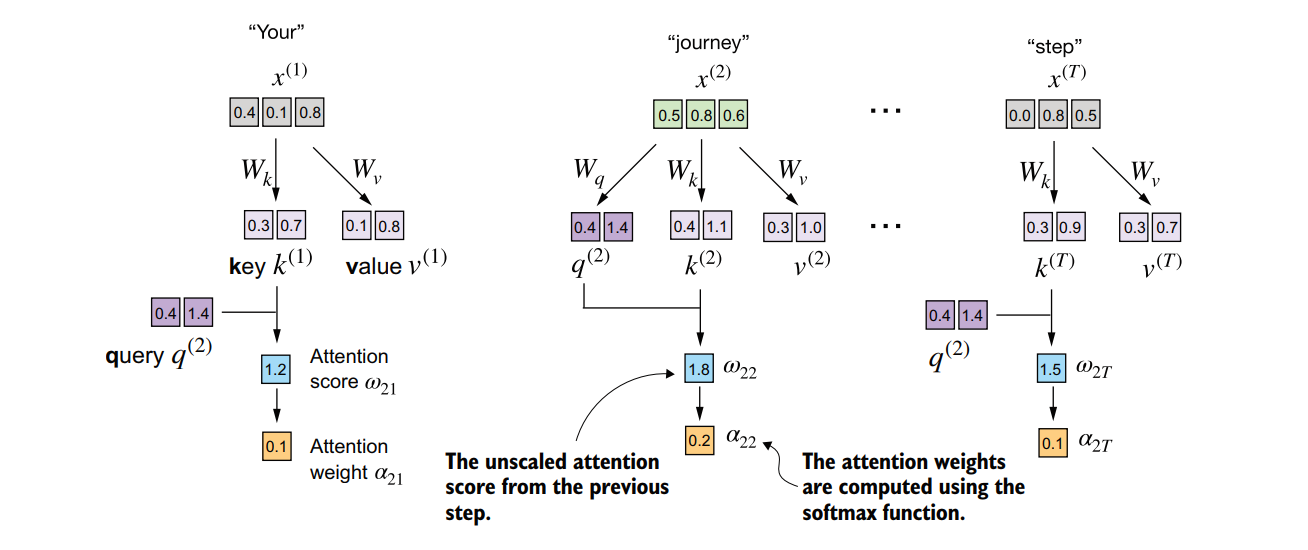

# Compact Class

In [45]:
import torch.nn as nn

class SelfAttentionV1(nn.Module):
    def __init__(self, d_in ,  d_out):
        super().__init__()
        self.w_q = nn.Parameter(torch.rand(d_in,d_out))
        self.w_k = nn.Parameter(torch.rand(d_in,d_out))
        self.w_v = nn.Parameter(torch.rand(d_in,d_out))

        #self.w_q = nn.Parameter(torch.rand(d_in,d_out))
        #self.w_k = nn.Parameter(torch.rand(d_in,d_out))
        #self.w_v = nn.Parameter(torch.rand(d_in,d_out))

        
    def forward(self,x):
        keys = x @ self.w_k
        #print(f"Keys : \n {keys}")
        values = x @ self.w_v
        #print(f"Values : \n {values}")
        queries = x @ self.w_q
        #print(f"Queries :\n {queries}")
        
        d_k = keys.shape[-1]

        attention_scores  = queries @ keys.T
        attention_weights = torch.softmax(attention_scores / d_k**0.5, dim =-1)
        context_vectors  = attention_weights @ values

        return context_vectors
    


In [46]:
torch.manual_seed(123)
#sa_V1 = self attention version 1
sa_v1 = SelfAttentionV1(d_in , d_out)

In [47]:
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [48]:
cont_vec_2

tensor([0.3061, 0.8210])

### Instead of using `nn.Parameter` 
- We will use `nn.Linear`
- Since nn.Linear is more effective in :
    - Matrix Multiplication
    - Has more Optimized weight init 
    - Optimized scheme, contributing to more stable training 

    
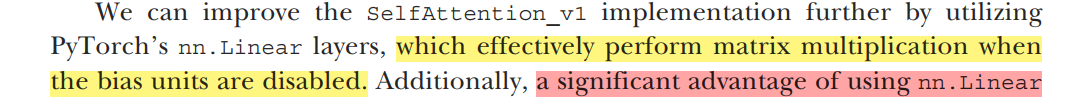
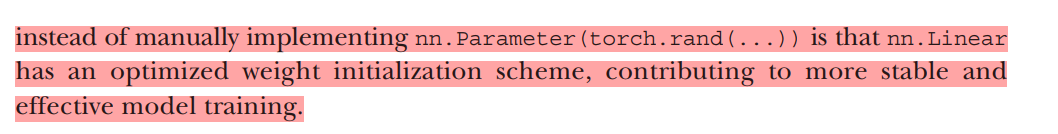

## Implementing Self Attention with `nn.linear`

In [49]:
class SelfAttentionV2(nn.Module):

    def __init__(self, d_in , d_out,q_k_v_bias = False):
        super().__init__()

        self.w_q = nn.Linear(d_in, d_out, bias = q_k_v_bias)
        self.w_k = nn.Linear(d_in, d_out, bias = q_k_v_bias)
        self.w_v = nn.Linear(d_in, d_out, bias=q_k_v_bias)

    def forward(self,x):

        queries = self.w_q(x)
        keys = self.w_k(x)
        values = self.w_v(x)

        attn_scores = queries  @ keys.T

        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5 , dim = -1)

        context_vectors  = attn_weights @ values

        return context_vectors
    


In [50]:
torch.manual_seed(789)

sa_v2 = SelfAttentionV2(d_in , d_out,False)

print(sa_v2(inputs))


tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


>> The values of `sa_v1` is different than `sa_v2`

- Because the `nn.Linear` has an optimized weighting initalization 



-----

#### To make sure that the the weight init is the only the key factor
- We will use the weights of the SelfAttentionV1 in the V2 and see the results



##### Important Note we need to declarify

- The weights in the `nn.Linear` are Transposed by nature, so we need to return it back to be used in `nn.Parameter`

In [174]:
torch.manual_seed(123)
sa_v1_w = SelfAttentionV1(d_in, d_out)

##### That is the weight in the `V1` of `nn.Parameter`


In [179]:
sa_v1_w.w_k

Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]], requires_grad=True)

In [180]:
sa_v1_w.w_k.data

tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])

##### That is the weight in `nn.Linear` 

- In Transposed Position

In [161]:
sa_v2.w_q.weight.data

tensor([[0.2961, 0.2517, 0.0740],
        [0.5166, 0.6886, 0.8665]])

### Important Note

#### To Access weights 

- In `nn.Parameter` : w_q 
- In `nn.Linear` : w_q.weight.data

##### Now we are going to replace the weights of the v2 with v1 

In [182]:
sa_v2.w_k.weight.data = sa_v1_w.w_k.data.T
sa_v2.w_q.weight.data = sa_v1_w.w_q.data.T
sa_v2.w_v.weight.data = sa_v1_w.w_v.data.T

In [183]:
sa_v2.w_k.weight

Parameter containing:
tensor([[0.1366, 0.1841, 0.3153],
        [0.1025, 0.7264, 0.6871]], requires_grad=True)

In [184]:
sa_v2(inputs)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

In [189]:
sa_v1(inputs)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

## Masked Self Attention

- **To Do masked self attention**

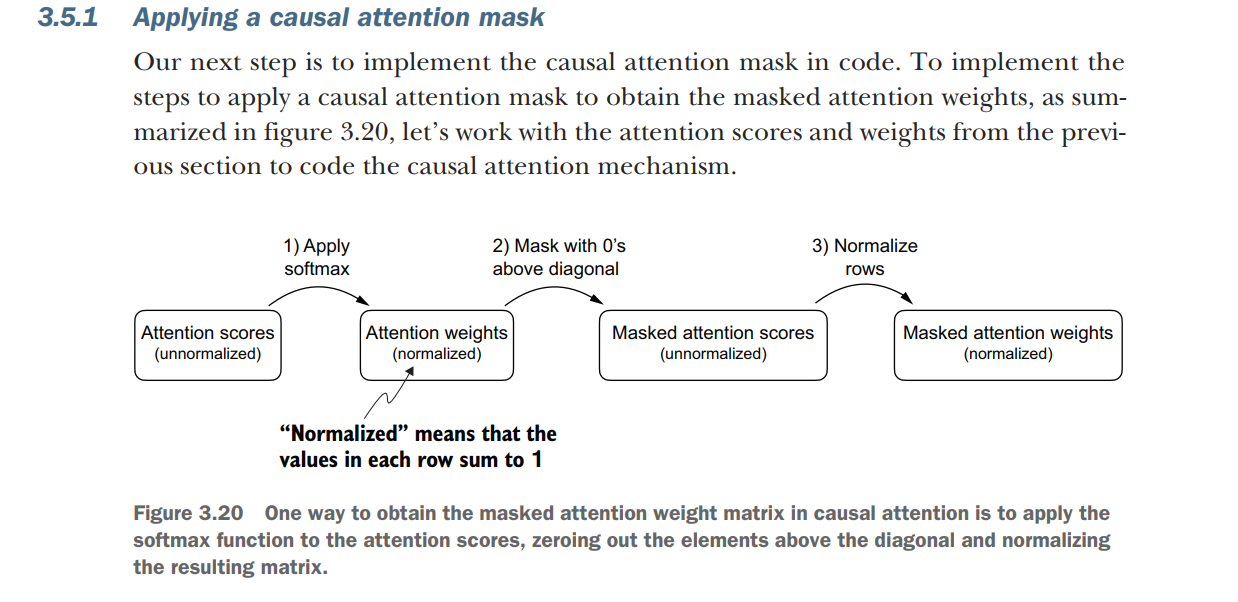

### Starting from SelfAttentionV2

In [120]:
# For the inputs --> we get the wq wk wv
queries = sa_v2.w_q(inputs) # (6,2)
keys = sa_v2.w_k(inputs) # (6,2)
values = sa_v2.w_v(inputs)
# getting the attention scores

attn_scores = queries @ keys.T

# getting attention weigths 

attn_weights = torch.softmax(attn_scores / keys.shape[-1] **0.5 , dim =0)
print(attn_weights)


tensor([[0.1605, 0.1608, 0.1610, 0.1632, 0.1669, 0.1607],
        [0.1818, 0.1727, 0.1727, 0.1679, 0.1720, 0.1676],
        [0.1810, 0.1724, 0.1725, 0.1679, 0.1717, 0.1677],
        [0.1576, 0.1643, 0.1642, 0.1670, 0.1626, 0.1681],
        [0.1526, 0.1626, 0.1624, 0.1669, 0.1605, 0.1683],
        [0.1664, 0.1672, 0.1672, 0.1671, 0.1663, 0.1675]],
       grad_fn=<SoftmaxBackward0>)


In [71]:
attn_scores.shape[0]

6

### Creating the masked attention 

#### `Torch.tril`

- It only returns the lower traingular part of a matrix 
- The values i need in the lower triangular part is determined by what you need 

##### Here i want the lower triangular part to be filled with random int

In [63]:
torch.tril(torch.tensor(torch.rand(4,4)))

C:\Users\omark\AppData\Local\Temp\ipykernel_27732\2130226260.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tril(torch.tensor(torch.rand(4,4)))


tensor([[0.3821, 0.0000, 0.0000, 0.0000],
        [0.6367, 0.9826, 0.0000, 0.0000],
        [0.2775, 0.8573, 0.8993, 0.0000],
        [0.9268, 0.7388, 0.7179, 0.7058]])

##### Here i want the lower triangular part to be filled with ones 

In [55]:
context_len = attn_scores.shape[0]
# shape of torch.ones equal to (context_len , context_len) --> (6,6)
mask_simple = torch.tril(torch.ones(context_len,context_len))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


#### Now we multiply the `mask_simple` with the `attention scores`

In [119]:
masked_self_attn = attn_weights * mask_simple
print(masked_self_attn)

tensor([[0.1605, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1818, 0.1727, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1810, 0.1724, 0.1725, 0.0000, 0.0000, 0.0000],
        [0.1576, 0.1643, 0.1642, 0.1670, 0.0000, 0.0000],
        [0.1526, 0.1626, 0.1624, 0.1669, 0.1605, 0.0000],
        [0.1664, 0.1672, 0.1672, 0.1671, 0.1663, 0.1675]],
       grad_fn=<MulBackward0>)


### Re-Normalize the attention weights

#### Getting the sum of each row 

- Then we divide each row by the sum of each row we get

In [75]:
rows_sums = masked_self_attn.sum(dim=-1,keepdim=True)
rows_sums

tensor([[0.1605],
        [0.3544],
        [0.5259],
        [0.6532],
        [0.8050],
        [1.0018]], grad_fn=<SumBackward1>)

In [77]:
masked_self_attn_norm = masked_self_attn / rows_sums
masked_self_attn_norm

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5129, 0.4871, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3442, 0.3279, 0.3280, 0.0000, 0.0000, 0.0000],
        [0.2413, 0.2516, 0.2514, 0.2557, 0.0000, 0.0000],
        [0.1896, 0.2020, 0.2018, 0.2073, 0.1993, 0.0000],
        [0.1661, 0.1669, 0.1669, 0.1668, 0.1660, 0.1672]],
       grad_fn=<DivBackward0>)

### More efficient Way to calc the masked attention

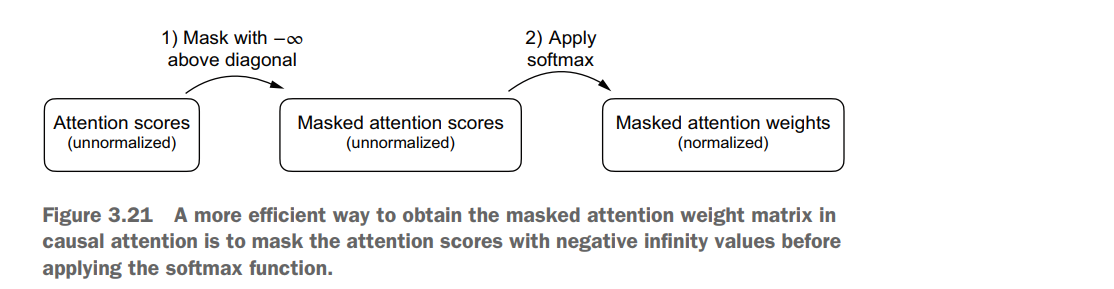




#### We mask with `-inf` to the above diagonal at first
- Then apply softmax --> Now its normalized

#### `torch.triu`

- It returns the values of the Upper triangular matrix only

In [79]:
torch.triu(torch.ones(6,6))

tensor([[1., 1., 1., 1., 1., 1.],
        [0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.]])

In [88]:
# diagonal = 1 --> means the diagonal itself is not included , if diagonal =0 --> then it will be included and equal to 1
mask = torch.triu(torch.ones(context_len,context_len) , diagonal=1)
mask

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])

##### `masked.fill`

**masked_fill(mask, value) -> Tensor**

it took the mask and replace the 1 with the values 

##### To apply the mask 
- It should took the mask as boolean values not 1 and 0

In [91]:
mask.bool()

tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])

In [127]:
masked = attn_scores.masked_fill(mask.bool()[:6 , :6],-torch.inf)
masked

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)

In [122]:
masked = attn_scores.masked_fill(mask.bool(),- torch.inf)
masked

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)

#### Then apply softmak directly

In [128]:
attn_weights_norm = torch.softmax(masked / keys.shape[-1] ** 0.5 , dim =-1)
attn_weights_norm

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

#### Use the modified version to calc the context vectors

In [98]:
context_vectors = attn_weights_norm @ values
context_vectors

tensor([[-0.0872,  0.0286],
        [-0.1004,  0.0525],
        [-0.1009,  0.0659],
        [-0.0985,  0.0488],
        [-0.0509,  0.1106],
        [-0.0772,  0.0664]], grad_fn=<MmBackward0>)

## Applying dropout

In [103]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)

print(f"Example : \n {example} \n\n")

print(f"Applying Dropout : \n{dropout(example)}")

Example : 
 tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]]) 


Applying Dropout : 
tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


#### Apply it to the attention weights 

In [104]:
torch.manual_seed(123)

print(dropout(attn_weights_norm))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6694, 0.6653, 0.6653, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5004, 0.5003, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4004, 0.0000, 0.4017, 0.0000, 0.0000],
        [0.0000, 0.3334, 0.3334, 0.3334, 0.3332, 0.0000]],
       grad_fn=<MulBackward0>)


## More Solid Self Attention Class

### We need to make sure that our class now can handle batches, so that we will duplicate the `inputs`

In [105]:
batch = torch.stack((inputs,inputs),dim =0)
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [107]:
batch.shape

torch.Size([2, 6, 3])

In [112]:
batch.transpose(1,2)

tensor([[[0.4300, 0.5500, 0.5700, 0.2200, 0.7700, 0.0500],
         [0.1500, 0.8700, 0.8500, 0.5800, 0.2500, 0.8000],
         [0.8900, 0.6600, 0.6400, 0.3300, 0.1000, 0.5500]],

        [[0.4300, 0.5500, 0.5700, 0.2200, 0.7700, 0.0500],
         [0.1500, 0.8700, 0.8500, 0.5800, 0.2500, 0.8000],
         [0.8900, 0.6600, 0.6400, 0.3300, 0.1000, 0.5500]]])

In [146]:
class CausalAttention(nn.Module):
    def __init__(self, d_in , d_out,context_length , dropout, kqv_bias = False):
        super().__init__()

        self.w_q = nn.Linear(d_in , d_out, bias = kqv_bias)
        self.w_k = nn.Linear(d_in , d_out, bias = kqv_bias)
        self.w_v = nn.Linear(d_in , d_out, bias = kqv_bias)
        self.dropout = torch.nn.Dropout(dropout)
        self.d_out = d_out

        # we use this to make sure that the tensor is moved to gpu or cpu along with the model
        # to prevent the problem of tensor is on cpu and model on gpu
        self.register_buffer("mask" , torch.triu(torch.ones(context_length,context_length),diagonal=1))


    def forward(self,x):
        b, num_tokens, d_in = x.shape
        keys = self.w_k(x)
        queries = self.w_q(x)
        values = self.w_v(x)

        attention_scores = queries @ keys.transpose(1,2) # keep batch as is, but transpose (context_length , d_in)

        # the last _ in (masked_fill_) --> tells pytorch to perform this operation in-place to save up memory 
        attention_scores.masked_fill_(self.mask.bool()[:num_tokens , :num_tokens] , -torch.inf)

        attention_weights = torch.softmax(attention_scores / d_out **0.5 , dim =-1)

        attention_weights = self.dropout(attention_weights)

        context_vectors = attention_weights @ values

        return context_vectors



In [147]:
torch.manual_seed(123)
context_len = batch.shape[1]
ca = CausalAttention(d_in , d_out,context_len , 0.0)
context_vectors = ca(batch)

print(f"Context vectors : \n {context_vectors} \n\n")
print(f"Context Vectors shape : {context_vectors.shape}")

Context vectors : 
 tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>) 


Context Vectors shape : torch.Size([2, 6, 2])


## Multi-Head Attention

### We can use the simple version of Multi-head attention

#### We can make multiple Attention using Loop over our last version of CausalAttention
- But it is inefficient 

In [139]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, kqv_bias=False):
        super().__init()
        self.heads = nn.ModuleList(

             [CausalAttention(d_in, d_out, context_length, dropout) for _ in range(num_heads)]
        )

    def forward(self,x):
        return torch.cat([head(x) for head in self.heads])
    


In [152]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, kqv_bias=False):
        
        super().__init__()
        self.heads = nn.ModuleList(

        [CausalAttention(d_in, d_out, context_length, dropout) for _ in range(num_heads)] )

        
    def forward(self,x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


In [153]:
torch.manual_seed(123)
context_len = batch.shape[1]
d_in , d_out = 3,2

mha = MultiHeadAttentionWrapper(d_in, d_out, context_len,0.0 , num_heads=2)
mha

MultiHeadAttentionWrapper(
  (heads): ModuleList(
    (0-1): 2 x CausalAttention(
      (w_q): Linear(in_features=3, out_features=2, bias=False)
      (w_k): Linear(in_features=3, out_features=2, bias=False)
      (w_v): Linear(in_features=3, out_features=2, bias=False)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
)

In [154]:
context_vectors = mha(batch)

##### As we see the shape become [2,6,4]

##### because each head produce output of 2-dim and then we concat them produce [6,4]

In [156]:
print(f" Context Vector shape : {context_vectors.shape}\n\n")
print(f" Context Vectors : {context_vectors}")

 Context Vector shape : torch.Size([2, 6, 4])


 Context Vectors : tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


#### `torch.cat`

**it concate tensors together**

- if dim =1 --> it concate rows together
    - Concat them first into one tensor in terms of row
    - Meaning stack them in row - basis

- if dim = 2 
    - Concat them first in one tensor 
    - Stack them in cols
    - The new batch will had addition cols 

In [158]:
x1 = torch.ones(1,4,4)
x1

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

In [163]:
torch.manual_seed(123)
x2 = torch.rand(1,4,4)
x2

tensor([[[0.2961, 0.5166, 0.2517, 0.6886],
         [0.0740, 0.8665, 0.1366, 0.1025],
         [0.1841, 0.7264, 0.3153, 0.6871],
         [0.0756, 0.1966, 0.3164, 0.4017]]])

In [170]:
torch.cat([x1,x2] , dim =2)

tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 0.2961, 0.5166, 0.2517, 0.6886],
         [1.0000, 1.0000, 1.0000, 1.0000, 0.0740, 0.8665, 0.1366, 0.1025],
         [1.0000, 1.0000, 1.0000, 1.0000, 0.1841, 0.7264, 0.3153, 0.6871],
         [1.0000, 1.0000, 1.0000, 1.0000, 0.0756, 0.1966, 0.3164, 0.4017]]])

In [171]:
torch.cat([x1,x2] , dim =1)

tensor([[[1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000],
         [0.2961, 0.5166, 0.2517, 0.6886],
         [0.0740, 0.8665, 0.1366, 0.1025],
         [0.1841, 0.7264, 0.3153, 0.6871],
         [0.0756, 0.1966, 0.3164, 0.4017]]])

In [172]:
torch.cat([x1,x2] , dim =0)

tensor([[[1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000]],

        [[0.2961, 0.5166, 0.2517, 0.6886],
         [0.0740, 0.8665, 0.1366, 0.1025],
         [0.1841, 0.7264, 0.3153, 0.6871],
         [0.0756, 0.1966, 0.3164, 0.4017]]])

## Exercise 3.2

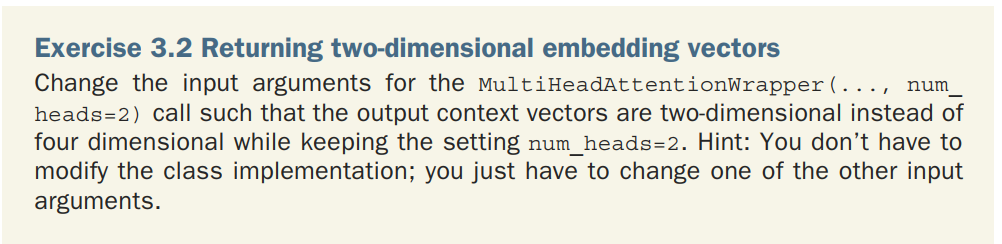

In [173]:
torch.manual_seed(123)
context_len = batch.shape[1]
d_in , d_out = 3,1

mha = MultiHeadAttentionWrapper(d_in, d_out, context_len,0.0 , num_heads=2)
mha

MultiHeadAttentionWrapper(
  (heads): ModuleList(
    (0-1): 2 x CausalAttention(
      (w_q): Linear(in_features=3, out_features=1, bias=False)
      (w_k): Linear(in_features=3, out_features=1, bias=False)
      (w_v): Linear(in_features=3, out_features=1, bias=False)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
)

In [174]:
context_vectors = mha(batch)

In [175]:
print(f" Context Vector shape : {context_vectors.shape}\n\n")
print(f" Context Vectors : {context_vectors}")

 Context Vector shape : torch.Size([2, 6, 2])


 Context Vectors : tensor([[[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]],

        [[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]]], grad_fn=<CatBackward0>)


##  Efficient MultiHead Implementation

In [178]:
512 // 8

64

In [186]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in , d_out, dropout ,num_heads , context_length , kqv_bias =False ):
        super().__init__()

        assert(d_out % num_heads ==0) , "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # i want the floor divison --> 512 // 8 = 64 , not for example 64.3 , i want the int


        self.w_q = nn.Linear(d_in , d_out, bias = kqv_bias)
        self.w_k = nn.Linear(d_in, d_out, bias = kqv_bias)
        self.w_v = nn.Linear(d_in, d_out, bias = kqv_bias)

        # Optional, we took different combination from the all heads together 
        self.out_proj = nn.Linear(d_out, d_out, bias =kqv_bias)

        # dropout

        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer("mask" , torch.triu(torch.ones(context_length,context_length),diagonal=1))

    

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        keys = self.w_k(x)
        queries = self.w_q(x)
        values = self.w_v(x)

        # view --> return a new tensor with the same data 
        # used to indtroduce a new dim but with keeping data as is
        # we will split d_out into (num_heads, head_dim)
            # if d_out = 512, splitting it into 8 * 64 --> giving the same 512

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        values = values.view(b, num_tokens, self.num_heads, self.head_dim)


        # transpose: used to swap `transposed` the dimensions 

        # now this becomes (b, num_heads, num_tokens , head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        attention_scores = queries @ keys.transpose(2,3)

        mask_bool = self.mask.bool()[:num_tokens , :num_tokens]

        attention_scores.masked_fill_(mask_bool, -torch.inf)


        # both are right

        #attention_weights = torch.softmax(attention_scores / self.head_dim **0.5 , dim=-1)
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] **0.5 , dim=-1)

        attention_weights = self.dropout(attention_weights)

        # returning everything at in the first place
        # return to (b, num_tokens, num_heads, head_dim)
        context_vectors = (attention_weights @ values).transpose(1,2)

        # returns to (b, num_tokens, d_out)
        context_vectors = context_vectors.contiguous().view(b, num_tokens, self.d_out)

        # final projection to get different combination

        context_vectors = self.out_proj(context_vectors)

        return context_vectors



In [187]:
torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out =2

mha = MultiHeadAttention(d_in , d_out, 0.0 , 2, context_length)
print(mha)

MultiHeadAttention(
  (w_q): Linear(in_features=3, out_features=2, bias=False)
  (w_k): Linear(in_features=3, out_features=2, bias=False)
  (w_v): Linear(in_features=3, out_features=2, bias=False)
  (out_proj): Linear(in_features=2, out_features=2, bias=False)
  (dropout): Dropout(p=0.0, inplace=False)
)


In [188]:
context_vectors = mha(batch)
print(context_vectors)

tensor([[[ 0.1257, -0.1968],
         [ 0.1010, -0.2929],
         [ 0.0922, -0.3233],
         [ 0.0759, -0.2952],
         [ 0.0705, -0.2897],
         [ 0.0641, -0.2798]],

        [[ 0.1257, -0.1968],
         [ 0.1010, -0.2929],
         [ 0.0922, -0.3233],
         [ 0.0759, -0.2952],
         [ 0.0705, -0.2897],
         [ 0.0641, -0.2798]]], grad_fn=<UnsafeViewBackward0>)


### Exercise 3.3

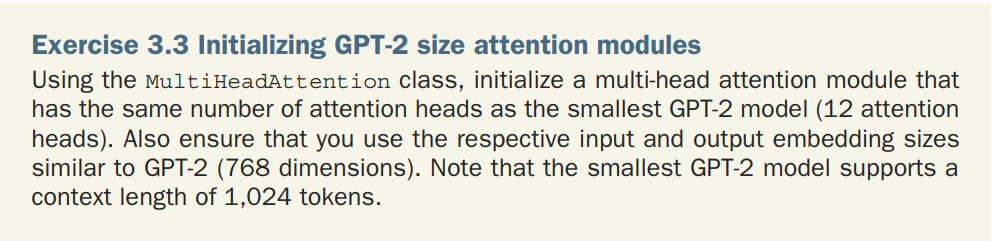

In [189]:
torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out =768

mha = MultiHeadAttention(d_in , d_out, 0.0 , 12, context_length)
print(mha)

MultiHeadAttention(
  (w_q): Linear(in_features=3, out_features=768, bias=False)
  (w_k): Linear(in_features=3, out_features=768, bias=False)
  (w_v): Linear(in_features=3, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=False)
  (dropout): Dropout(p=0.0, inplace=False)
)


In [190]:
context_vector = mha(batch)

In [191]:
context_vector.shape

torch.Size([2, 6, 768])

In [192]:
print(context_vector)

tensor([[[-0.0122, -0.1146, -0.1229,  ...,  0.3513,  0.2643,  0.0346],
         [-0.1062, -0.1601, -0.0785,  ...,  0.4075,  0.2007,  0.0873],
         [-0.1342, -0.1714, -0.0664,  ...,  0.4195,  0.1768,  0.1026],
         [-0.1365, -0.1625, -0.0447,  ...,  0.3773,  0.1424,  0.1008],
         [-0.1095, -0.1242, -0.0650,  ...,  0.3258,  0.1287,  0.0834],
         [-0.1243, -0.1409, -0.0426,  ...,  0.3415,  0.1161,  0.0887]],

        [[-0.0122, -0.1146, -0.1229,  ...,  0.3513,  0.2643,  0.0346],
         [-0.1062, -0.1601, -0.0785,  ...,  0.4075,  0.2007,  0.0873],
         [-0.1342, -0.1714, -0.0664,  ...,  0.4195,  0.1768,  0.1026],
         [-0.1365, -0.1625, -0.0447,  ...,  0.3773,  0.1424,  0.1008],
         [-0.1095, -0.1242, -0.0650,  ...,  0.3258,  0.1287,  0.0834],
         [-0.1243, -0.1409, -0.0426,  ...,  0.3415,  0.1161,  0.0887]]],
       grad_fn=<UnsafeViewBackward0>)
